In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('dark_background')

from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/AIML/Dataset/Social_Network_Ads.csv')
dataset = data
dataset

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [92]:
X = dataset.iloc[:,2:-1].values
Y = dataset.iloc[:,-1].values

In [93]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X = sc.fit_transform(X)

In [94]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.25,random_state=0)

In [95]:
from sklearn.linear_model import LogisticRegression

classifire = LogisticRegression(random_state=0)
classifire.fit(X_train,Y_train)

LogisticRegression(random_state=0)

In [96]:
pred = classifire.predict(X_test)
pred

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1])

In [97]:
from sklearn.metrics import confusion_matrix

ans = confusion_matrix(Y_test,pred)
ans

array([[65,  3],
       [ 8, 24]])

In [98]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,pred))

              precision    recall  f1-score   support

           0       0.89      0.96      0.92        68
           1       0.89      0.75      0.81        32

    accuracy                           0.89       100
   macro avg       0.89      0.85      0.87       100
weighted avg       0.89      0.89      0.89       100



/tmp/ipython-input-3587665460.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[Y_set == j, 0], X_set[Y_set == j, 1],


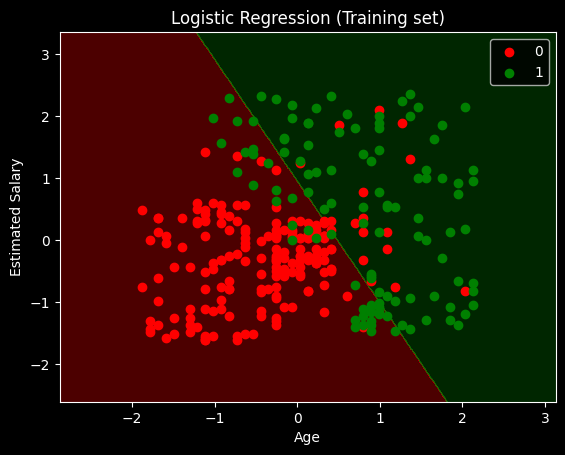

In [99]:

from matplotlib.colors import ListedColormap
X_set, Y_set = X_train, Y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifire.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.3, cmap = ListedColormap(('red', 'green')))
# plt.xlim(X1.min(), X1.max())
# plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(Y_set)):
    plt.scatter(X_set[Y_set == j, 0], X_set[Y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Logistic Regression (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()


/tmp/ipython-input-918423974.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[Y_set == j, 0], X_set[Y_set == j, 1],


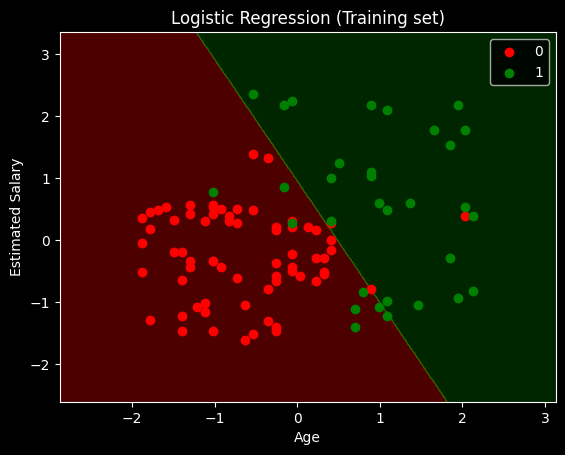

In [100]:

from matplotlib.colors import ListedColormap
X_set, Y_set = X_test, Y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifire.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.3, cmap = ListedColormap(('red', 'green')))
# plt.xlim(X1.min(), X1.max())
# plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(Y_set)):
    plt.scatter(X_set[Y_set == j, 0], X_set[Y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Logistic Regression (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()


In [101]:
from sklearn.metrics import confusion_matrix

ans = confusion_matrix(Y_test,pred)
ans

array([[65,  3],
       [ 8, 24]])

---
with gender

In [102]:
from sklearn.preprocessing import LabelEncoder

data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/AIML/Dataset/Social_Network_Ads.csv')
dataset = data
dataset
X = dataset.iloc[:,1:-1].values
y = dataset.iloc[:,-1].values
le = LabelEncoder()
X[:,0] = le.fit_transform(X[:,0])

In [103]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
classifire = LogisticRegression(random_state=0)
sc = StandardScaler()
X[:,1:] = sc.fit_transform(X[:,1:])

In [104]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test  = train_test_split(X,y,test_size=0.2,random_state=1)

In [105]:
from sklearn.linear_model import LogisticRegression

classifire = LogisticRegression(random_state=1)
classifire.fit(X_train,y_train)
pred = classifire.predict(X_test)
conf = confusion_matrix(pred,y_test)
report = classification_report(pred,y_test)
print(conf)
print(report)

[[40  6]
 [ 8 26]]
              precision    recall  f1-score   support

           0       0.83      0.87      0.85        46
           1       0.81      0.76      0.79        34

    accuracy                           0.82        80
   macro avg       0.82      0.82      0.82        80
weighted avg       0.82      0.82      0.82        80



----

In [106]:
#testing
from sklearn.preprocessing import LabelEncoder

data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/AIML/Dataset/Social_Network_Ads.csv')
dataset = data
dataset
X = dataset.iloc[:,2:-1].values
y = dataset.iloc[:,-1].values

In [107]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
classifire = LogisticRegression(random_state=0)
sc = StandardScaler()
X= sc.fit_transform(X)


In [108]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test  = train_test_split(X,y,test_size=0.2,random_state=1)

In [109]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report

classifire = LogisticRegression(random_state=1)
classifire.fit(X_train,y_train)
pred = classifire.predict(X_test)
conf = confusion_matrix(pred,y_test)
report = classification_report(pred,y_test)
print(conf)
print(report)

[[41  6]
 [ 7 26]]
              precision    recall  f1-score   support

           0       0.85      0.87      0.86        47
           1       0.81      0.79      0.80        33

    accuracy                           0.84        80
   macro avg       0.83      0.83      0.83        80
weighted avg       0.84      0.84      0.84        80

